In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Open dataset
ds = xr.open_dataset('/home/users/bidyut/UoE/20260112_Basic_Analysis/MSE_daily_flux_components.nc')



In [2]:
print(ds)

<xarray.Dataset> Size: 4GB
Dimensions:      (lat: 145, lon: 192, time: 720, plev: 8)
Coordinates:
  * lat          (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon          (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * time         (time) object 6kB 2001-01-01 12:00:00 ... 2002-12-30 12:00:00
  * plev         (plev) float64 64B 1e+05 8.5e+04 7e+04 ... 1e+04 5e+03 1e+03
Data variables:
    Flambda_div  (time, lat, lon) float32 80MB ...
    Fphi_div     (time, lat, lon) float32 80MB ...
    h_on_v       (time, plev, lat, lon) float32 641MB ...
    v_mean       (time, plev, lat, lon) float32 641MB ...
    v_corr       (time, plev, lat, lon) float64 1GB ...
    vh           (time, plev, lat, lon) float64 1GB ...
    vh_int       (time, lat, lon) float64 160MB ...


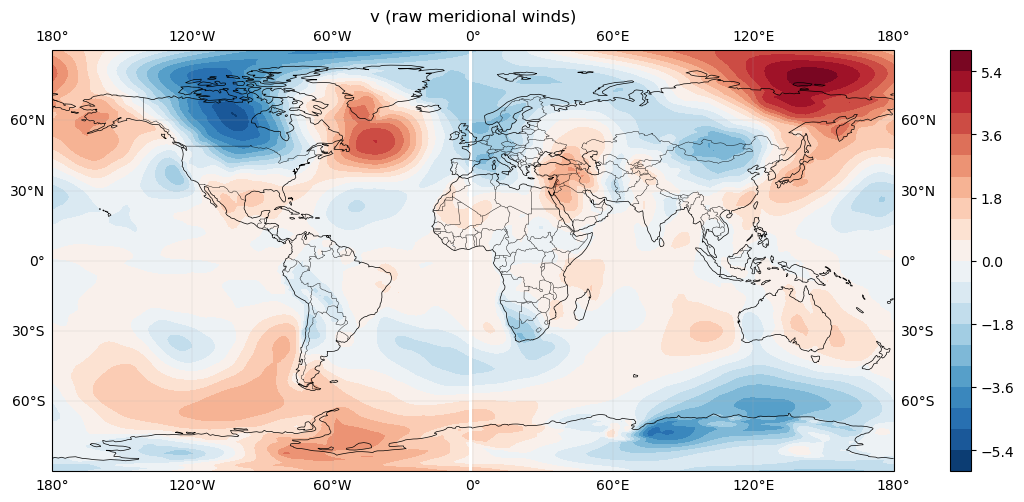

In [8]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
# v = ds['v_mean'].mean(dim="time") 
v = ds['v_mean'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.lon, ds.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("v (raw meridional winds)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



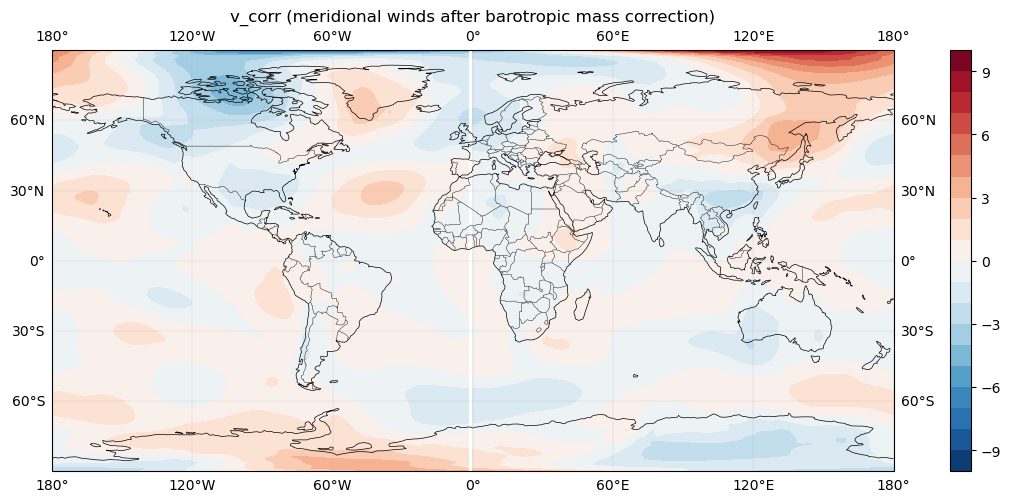

In [9]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
# v = ds['v_mean'].mean(dim="time") 
v = ds['v_corr'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.lon, ds.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("v_corr (meridional winds after barotropic mass correction)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



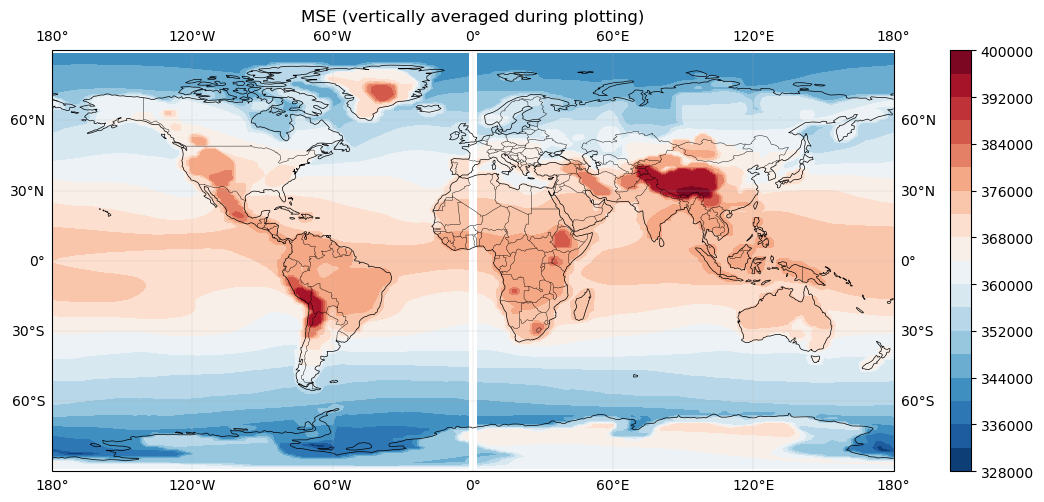

In [13]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
# v = ds['v_mean'].mean(dim="time") 
v = ds['h_on_v'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.lon, ds.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("MSE (vertically averaged during plotting)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



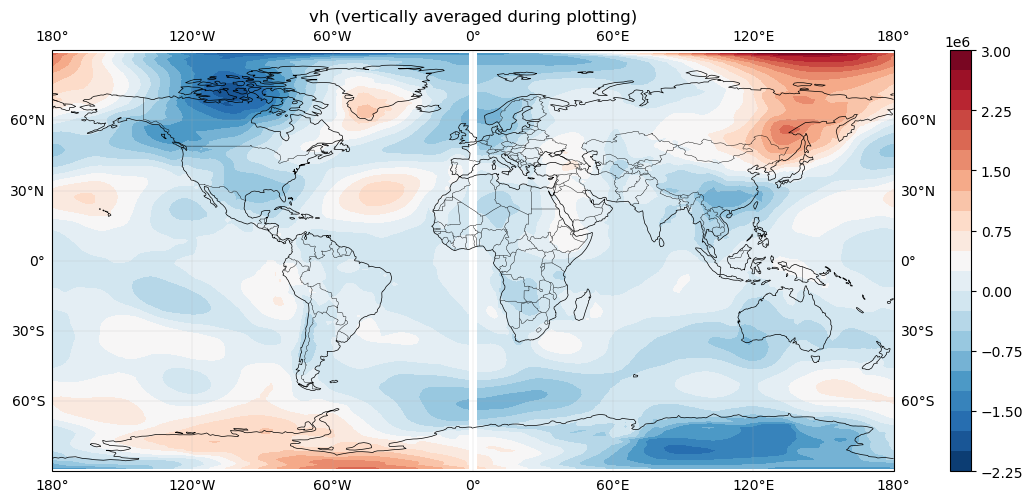

In [14]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
# v = ds['v_mean'].mean(dim="time") 
v = ds['vh'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.lon, ds.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("vh (vertically averaged during plotting)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



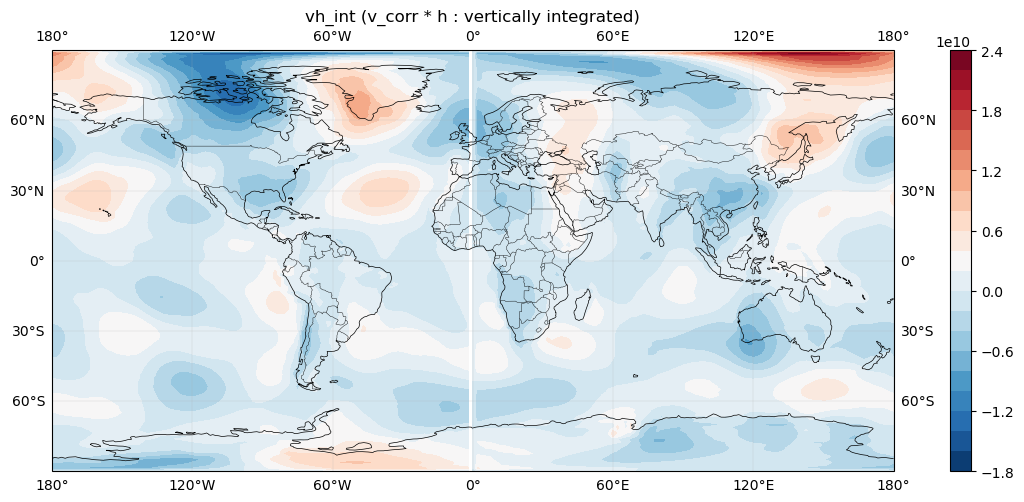

In [16]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
v = ds['vh_int'].mean(dim="time").sel(lat=slice(-90,90))
# v = ds['vh'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.lon, v.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("vh_int (v_corr * h : vertically integrated)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

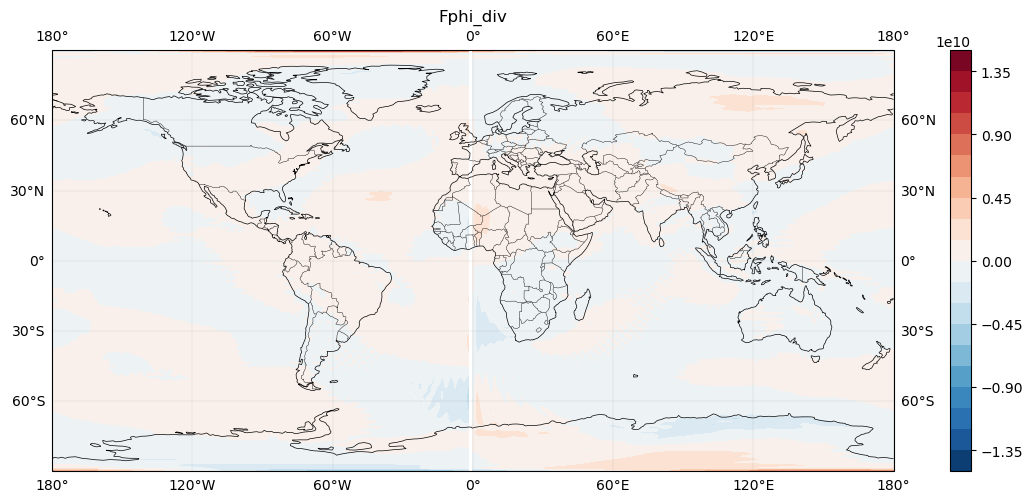

In [7]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
v = ds['Fphi_div'].mean(dim="time").sel(lat=slice(-90,90))
# v = ds['vh'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.lon, v.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("Fphi_div")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

In [ ]:
ds = xr.open_dataset('/home/users/bidyut/UoE/20260112_Basic_Analysis/MSE_daily_flux_components_NoBarotropCorr.nc')
